Por favor, introduce la ruta de la imagen (incluyendo la extensión): /content/entorno.jpg


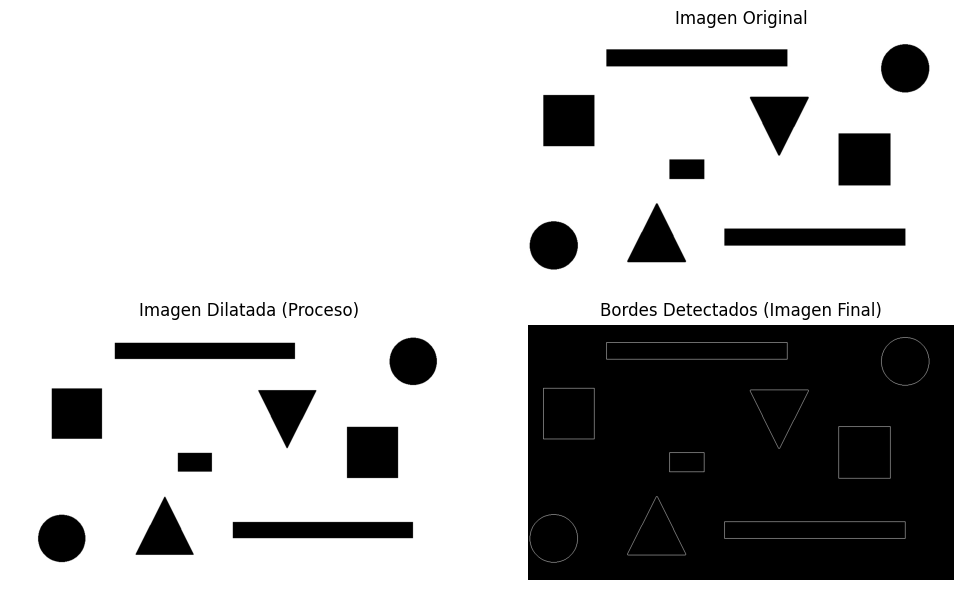

In [4]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from skimage import color, io
from skimage.morphology import dilation, disk
from skimage.filters import threshold_otsu


# Función para cargar y procesar la imagen
def cargarImagen():
    # Solicitar al usuario la ruta de la imagen
    file_path = input("Por favor, introduce la ruta de la imagen (incluyendo la extensión): ")

    try:
        # Leer la imagen
        img = io.imread(file_path)

        # Convertir a escala de grises si es necesario
        if img.ndim == 3:  # Imagen con 3 canales (RGB)
            img_gray = color.rgb2gray(img)
        else:
            img_gray = img

        # Binarizar la imagen usando Otsu
        thresh = threshold_otsu(img_gray)
        img_bw = img_gray > thresh

        # Crear el elemento estructurante (disco)
        selem = disk(1)

        # Dilatar la imagen binarizada
        img_proceso = dilation(img_bw, selem)

        # Calcular el gradiente morfológico (bordes detectados)
        img_bordes = img_proceso.astype(int) - img_bw.astype(int)

        # Mostrar las imágenes
        mostrarImagenes(img_gray, img_proceso, img_bordes)

    except FileNotFoundError:
        print("Archivo no encontrado. Asegúrate de que la ruta es correcta.")


# Función para mostrar las imágenes en la ventana
def mostrarImagenes(imagen_original, imagen_proceso, imagen_bordes):
    # Crear una nueva figura de matplotlib
    fig, axs = plt.subplots(2, 2, figsize=(10, 6))

    # Imagen original (arriba, centrada)
    axs[0, 1].imshow(imagen_original, cmap='gray')
    axs[0, 1].set_title('Imagen Original')
    axs[0, 1].axis('off')

    # Imagen del proceso (abajo a la izquierda)
    axs[1, 0].imshow(imagen_proceso, cmap='gray')
    axs[1, 0].set_title('Imagen Dilatada (Proceso)')
    axs[1, 0].axis('off')

    # Imagen de los bordes detectados (abajo a la derecha)
    axs[1, 1].imshow(imagen_bordes, cmap='gray')
    axs[1, 1].set_title('Bordes Detectados (Imagen Final)')
    axs[1, 1].axis('off')

    # Ocultar el subplot vacío
    axs[0, 0].axis('off')

    # Mostrar la figura
    plt.tight_layout()
    plt.show()


# Ejecutar la función para cargar y procesar la imagen
cargarImagen()
